# CAMS Air Pollution - flash-aurora Engine

Same setup as the upstream [Microsoft Aurora CAMS example](microsoft-aurora/docs/example_cams.ipynb):

- **Date:** 2022-06-11 (analysis at UTC 12:00 from 00:00 + 12:00 inputs)
- **Rollout:** 4 steps → 12 Jun 00/12 and 13 Jun 00/12 UTC
- **Model:** `AuroraAirPollution` via preset `cams`

`CamsAdapter` reads cached NetCDF under `<ASSET_ROOT>/cams/` and loads pollution static fields from `aurora-0.4-air-pollution-static.pickle` in `ASSET_ROOT`.

> **ADS endpoint:** CAMS uses the [Atmosphere Data Store](https://ads.atmosphere.copernicus.eu/). `DataDownloader` always talks to the ADS API URL for you—the same Copernicus UID key as CDS works; you do **not** need to edit `url` in `~/.cdsapirc`.

> **Asset root:** default is `./assets` under the working directory. To reuse a team data disk, uncomment `ASSET_ROOT = Path("/root/autodl-tmp/aurora")` in the setup cell. Saved notebook outputs may show whichever path was active when the tutorial was run.

## Prerequisites

1. **ADS account** and accepted dataset terms for [CAMS global composition forecasts](https://ads.atmosphere.copernicus.eu/datasets/cams-global-atmospheric-composition-forecasts).
2. **ADS credentials** (any one): `ADSAPI_KEY`, `CDSAPI_KEY` (same UID key), `~/.cdsapirc` (`key:` line only), or interactive `getpass` below.
3. **Checkpoint** and **`aurora-0.4-air-pollution-static.pickle`** under `ASSET_ROOT`, or Hugging Face download in the setup cell (independent of ADS ingress in section 1).


In [4]:
from datetime import datetime
from pathlib import Path

from flash_aurora.engine import (
    DEFAULT_PRESETS,
    DataDownloader,
    HF_MIRROR_ENDPOINT,
)
from flash_aurora.engine.core.redaction import safe_path

PRESET = "cams"
VALID_TIME = datetime(2022, 6, 11, 12)
TIME_INDEX = 1
ROLLOUT_STEPS = 4

# Named tier or combo: backbone@encoder_decoder (see README).
INFERENCE_PRECISION = "bf16_mixed@fp32"

# Default: ./assets under the notebook working directory (created if missing).
ASSET_ROOT: Path | str | None = None

# Optional — absolute path to a mounted data disk with checkpoints/cache (uncomment to use):
ASSET_ROOT = Path("/root/autodl-tmp/aurora")

if ASSET_ROOT is not None:
    root = Path(ASSET_ROOT).expanduser()
    if not root.is_absolute():
        raise ValueError("ASSET_ROOT must be an absolute path")
    ASSET_ROOT = root.resolve()
else:
    ASSET_ROOT = (Path.cwd() / "assets").resolve()
    ASSET_ROOT.mkdir(parents=True, exist_ok=True)

variant = DEFAULT_PRESETS.get(PRESET).variant
CHECKPOINT_PATH = ASSET_ROOT / variant.checkpoint_filename
USE_HF_MIRROR = False  # True -> https://hf-mirror.com when huggingface.co is blocked

if CHECKPOINT_PATH.is_file():
    CHECKPOINT_ARG = CHECKPOINT_PATH
    ALLOW_HUB_DOWNLOAD = False
    HF_ENDPOINT = None
    print("checkpoint: local", safe_path(CHECKPOINT_PATH))
else:
    CHECKPOINT_ARG = None
    ALLOW_HUB_DOWNLOAD = True
    HF_ENDPOINT = HF_MIRROR_ENDPOINT if USE_HF_MIRROR else None
    print("checkpoint: missing locally; will download from Hugging Face")
    print("  target dir:", safe_path(ASSET_ROOT))
    print("  filename:", variant.checkpoint_filename)
    print("  hf_endpoint:", HF_ENDPOINT or "https://huggingface.co (default)")

downloader = DataDownloader.from_preset(PRESET, asset_root=ASSET_ROOT)
cache_dir = downloader.resolve_cache_dir()

print("cache_dir:", safe_path(cache_dir))
print("asset_root:", safe_path(ASSET_ROOT))
print("allow_hub_download:", ALLOW_HUB_DOWNLOAD)

from flash_aurora.engine.core.hub import HubDownloadOptions
from flash_aurora.engine.core.paths import AssetStore

# Static fields from Hugging Face (file lives in ASSET_ROOT, not under the ingress cache).
STATIC_PICKLE_PATH = ASSET_ROOT / variant.static_pickle
HF_OPTIONS = HubDownloadOptions(
    endpoint=HF_MIRROR_ENDPOINT if USE_HF_MIRROR else HF_ENDPOINT,
)
if STATIC_PICKLE_PATH.is_file():
    print("static_pickle: local", safe_path(STATIC_PICKLE_PATH))
else:
    print("static_pickle: missing locally; will download from Hugging Face")
    print("  target dir:", safe_path(ASSET_ROOT))
    print("  filename:", variant.static_pickle)
    print("  hf_endpoint:", HF_OPTIONS.endpoint or "https://huggingface.co (default)")
    STATIC_PICKLE_PATH = AssetStore(root=ASSET_ROOT).fetch_hub_file(
        variant.static_pickle,
        repo=variant.hf_repo,
        allow_download=True,
        explicit=ASSET_ROOT,
        hub=HF_OPTIONS,
    )
    print("static_pickle: ready", safe_path(STATIC_PICKLE_PATH))


checkpoint: local ~/autodl-tmp/aurora/aurora-0.4-air-pollution.ckpt
cache_dir: ~/autodl-tmp/aurora/cams
asset_root: ~/autodl-tmp/aurora
allow_hub_download: False
static_pickle: local ~/autodl-tmp/aurora/aurora-0.4-air-pollution-static.pickle


## 1. Download CAMS (ADS API)

`DataDownloader.ensure()` retrieves the upstream CAMS zip from ADS, unpacks surface and atmospheric NetCDF files under `<ASSET_ROOT>/cams/`, and skips the API call when the cache is already complete.


In [5]:
import getpass
import os
from pathlib import Path

from flash_aurora.engine import DownloadResult
from flash_aurora.engine.core.redaction import safe_path
from flash_aurora.engine.ingress.download.paths import read_cdsapirc_key

missing = downloader.missing(VALID_TIME)

if missing:
    # ADS credentials only when a download is actually needed.
    # 1) Environment: export ADSAPI_KEY=your-key  (or CDSAPI_KEY — same Copernicus UID)
    # 2) Inline assignment for local testing only — do not commit keys to git
    # 3) Interactive getpass — paste into the hidden input when prompted
    ADS_API_KEY = (
        os.environ.get("ADSAPI_KEY", "").strip()
        or os.environ.get("CDSAPI_KEY", "").strip()
        or read_cdsapirc_key()
        or None
    )
    # ADS_API_KEY = "paste-your-ads-key-here"
    if ADS_API_KEY is None:
        ADS_API_KEY = getpass.getpass("ADS API key (Copernicus UID): ").strip() or None

    if not ADS_API_KEY:
        raise ValueError(
            "No ADS credentials found. Set ADSAPI_KEY, CDSAPI_KEY, add key: to ~/.cdsapirc, "
            "or paste your key when prompted by getpass."
        )

    print("Missing CAMS files:", missing)
    result = downloader.ensure(VALID_TIME, ads_api_key=ADS_API_KEY)
else:
    print("CAMS cache already complete under", safe_path(cache_dir))
    result = DownloadResult(
        cache_dir=cache_dir,
        paths=downloader.expected_paths(VALID_TIME),
        downloaded=(),
        skipped=tuple(downloader.expected_paths(VALID_TIME)),
    )

print("downloaded:", result.downloaded)
print("skipped:", result.skipped)
for key, path in result.paths.items():
    print(f"  {key}: {safe_path(path)}")


CAMS cache already complete under ~/autodl-tmp/aurora/cams
downloaded: ()
skipped: ('surface', 'atmospheric')
  surface: ~/autodl-tmp/aurora/cams/2022-06-11-cams-surface-level.nc
  atmospheric: ~/autodl-tmp/aurora/cams/2022-06-11-cams-atmospheric.nc


## 2–3. Build Initial Condition, load model, rollout

`CamsAdapter` selects `forecast_period=0` (analysis) and uses the latest `valid_time` (UTC 12) as IC metadata — same semantics as upstream.


In [6]:
import torch

from flash_aurora.engine import AuroraEngine, InitialConditionBuilder
from flash_aurora.aurora.model.inference_precision import describe_inference_config

engine = AuroraEngine.from_preset(
    PRESET,
    asset_root=ASSET_ROOT,
    checkpoint_path=CHECKPOINT_ARG,
    allow_hub_download=ALLOW_HUB_DOWNLOAD,
    hf_mirror=USE_HF_MIRROR,
    hf_endpoint=None if USE_HF_MIRROR else HF_ENDPOINT,
)

# Must be set before load() — see README "Inference precision tiers".
engine.config.inference_precision = INFERENCE_PRECISION

request = downloader.ingest_request(
    VALID_TIME,
    time_index=TIME_INDEX,
    download=False,
)
builder = InitialConditionBuilder(engine.config)
batch = builder.from_source(request)
print("IC time:", batch.metadata.time)
print("spatial:", batch.spatial_shape)

engine.load()
print("device:", next(engine.model.parameters()).device)

cfg = engine.model.inference_config
if cfg is not None:
    print("inference tier:", cfg.config_label)
    print(describe_inference_config(cfg))

with torch.inference_mode():
    preds = engine.run_from_adapter(request, steps=ROLLOUT_STEPS)

preds = [pred.to("cpu") for pred in preds]
print("predictions:", [str(p.metadata.time[0]) for p in preds])


IC time: (datetime.datetime(2022, 6, 11, 12, 0),)
spatial: torch.Size([451, 900])
device: cuda:0
inference tier: bf16_mixed@fp32
backbone matmul hybrid: BF16 attention QKV/proj + BF16 MLP; TF32 elsewhere; encoder/decoder matmul FP32 (native Perceiver SDPA); Triton layout+AdaLN; CuTe window attention (bfloat16); backbone activations float32
predictions: ['2022-06-12 00:00:00', '2022-06-12 12:00:00', '2022-06-13 00:00:00', '2022-06-13 12:00:00']


## 4. Visualize pollution fields

2×2 panels of **Aurora predictions** for each rollout step (12 Jun 00/12 and 13 Jun 00/12 UTC). Units scaled.


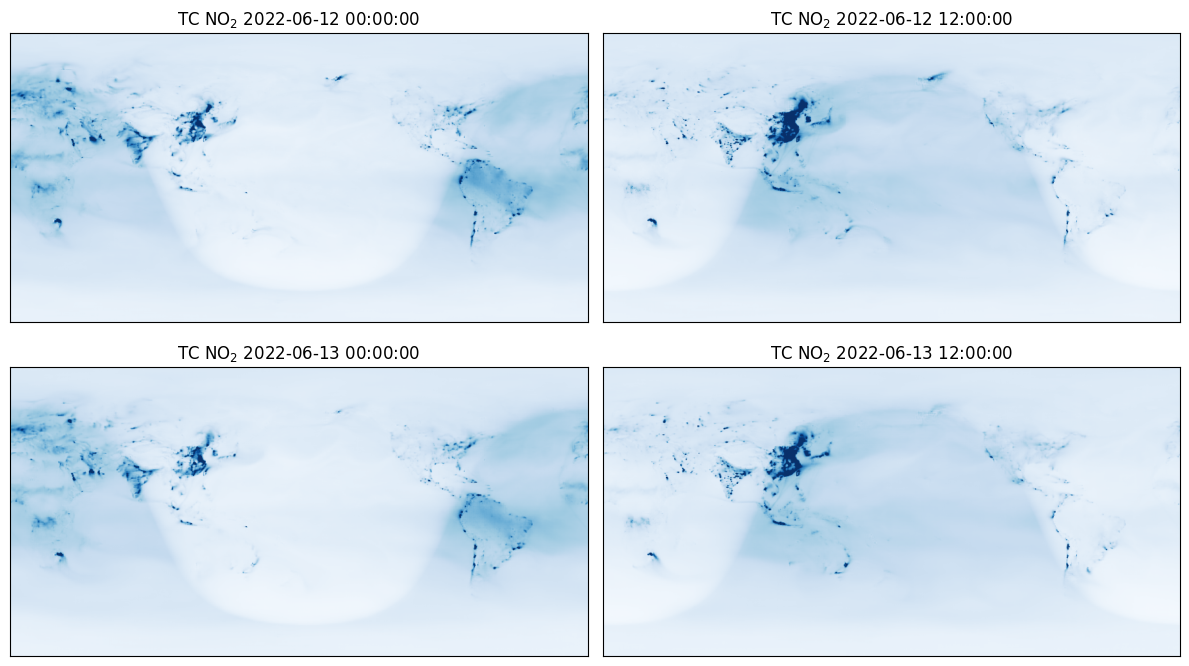

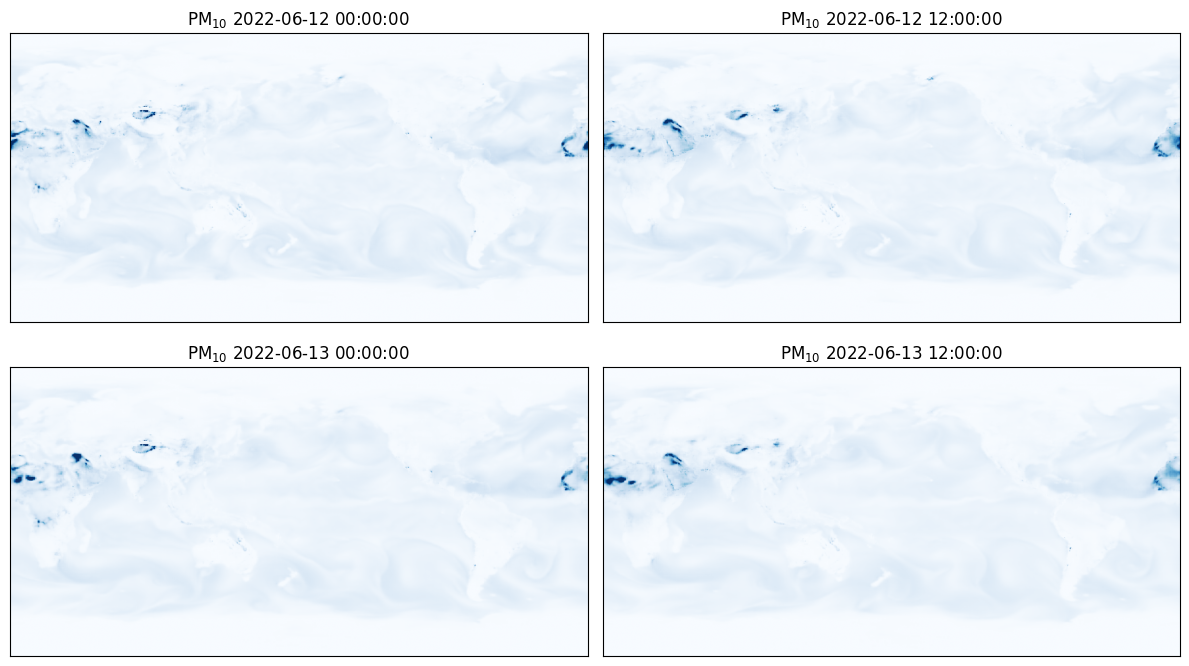

In [7]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 2, figsize=(12, 7))
for i in range(4):
    ax = axs[i // 2, i % 2]
    pred = preds[i]
    ax.imshow(pred.surf_vars["tcno2"][0, 0].numpy() / 1e-6, vmin=0, vmax=10, cmap="Blues")
    ax.set_title(f"TC NO$_2$ {pred.metadata.time[0]}")
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

fig, axs = plt.subplots(2, 2, figsize=(12, 7))
for i in range(4):
    ax = axs[i // 2, i % 2]
    pred = preds[i]
    ax.imshow(pred.surf_vars["pm10"][0, 0].numpy() / 1e-9, vmin=0, vmax=400, cmap="Blues")
    ax.set_title(f"PM$_{{10}}$ {pred.metadata.time[0]}")
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()


## 5. (Optional) Export rollout to NetCDF


In [8]:
# Model already on GPU from section 3.
EXPORT_DIR = ASSET_ROOT / "output" / PRESET
paths = list(engine.rollout_and_export(batch, steps=ROLLOUT_STEPS, export_dir=EXPORT_DIR))
for p in paths:
    print(safe_path(p), p.is_file())


~/autodl-tmp/aurora/output/cams/prediction-000.nc True
~/autodl-tmp/aurora/output/cams/prediction-001.nc True
~/autodl-tmp/aurora/output/cams/prediction-002.nc True
~/autodl-tmp/aurora/output/cams/prediction-003.nc True
